# Applying Image Processing Filters For Image Cartoonifying

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

## Importing Original Image

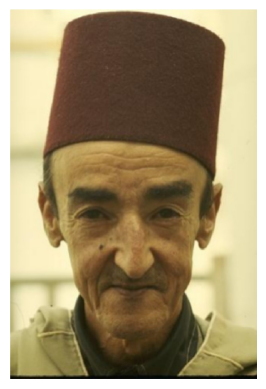

In [2]:
img = cv2.imread('example.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis('off')
plt.show()

## 1. Generating a black-and-white sketch
By converting RGB Image to grayscale

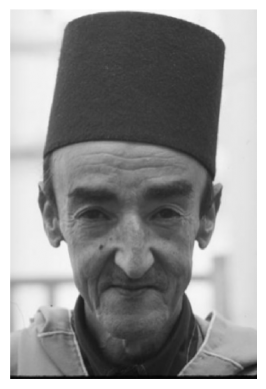

In [3]:
grayscale_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(grayscale_img, cmap='gray')
plt.axis('off')
plt.show()

### 1.1. Noise Reduction Using Median Filter

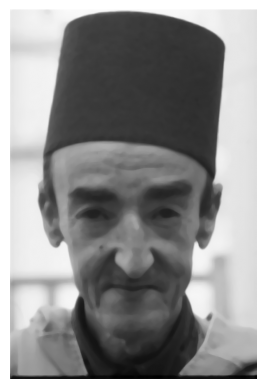

In [4]:
kernel_size = 11 # values 11 and 13 work fine in this case

smoothed_img = cv2.medianBlur(grayscale_img, kernel_size)

plt.imshow(smoothed_img, cmap='gray')
plt.axis('off')
plt.show()

### 1.2. Edge Detection Using Laplacian Filter

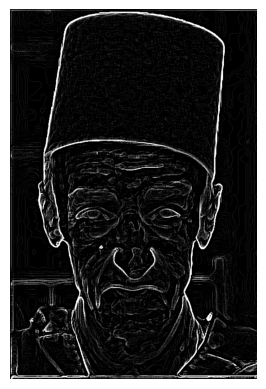

In [5]:
kernel_size = 5 # 5 works fine, rest don't work well

laplacian_img = cv2.Laplacian(smoothed_img, cv2.CV_8U, ksize=kernel_size)

plt.imshow(laplacian_img, cmap='gray')
plt.axis('off')
plt.show()

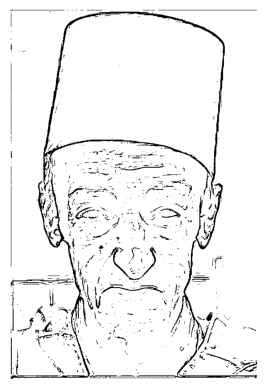

In [6]:
_, edge_mask = cv2.threshold(laplacian_img, 70, 255, cv2.THRESH_BINARY_INV)

plt.imshow(edge_mask, cmap='gray')
plt.axis('off')
plt.show()

## 2. Generating a Color Painting and a Cartoon

$$
BF[I]_p =
\frac{1}{W_p}
\sum_{q \in S}
G_{\sigma_s}(\|p-q\|)
G_{\sigma_r}(I_p - I_q)
I_q
$$

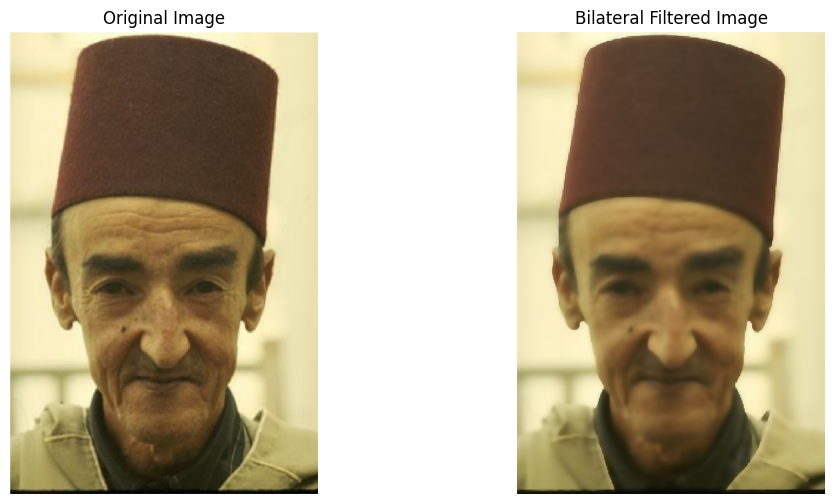

In [39]:
# apply bilateral filter to the original image
bilateral_filtered_img = img.copy()
for i in range(3):
    bilateral_filtered_img = cv2.bilateralFilter(bilateral_filtered_img, d=9, sigmaColor=75, sigmaSpace=75)
# d -> S
# sigmaColor -> sigma_r
# sigmaSpace -> sigma_s

# plot the orignal image and the filtered image side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img_rgb)
axes[1].imshow(cv2.cvtColor(bilateral_filtered_img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Image')
axes[1].set_title('Bilateral Filtered Image')
for ax in axes:
    ax.axis('off')
plt.show()

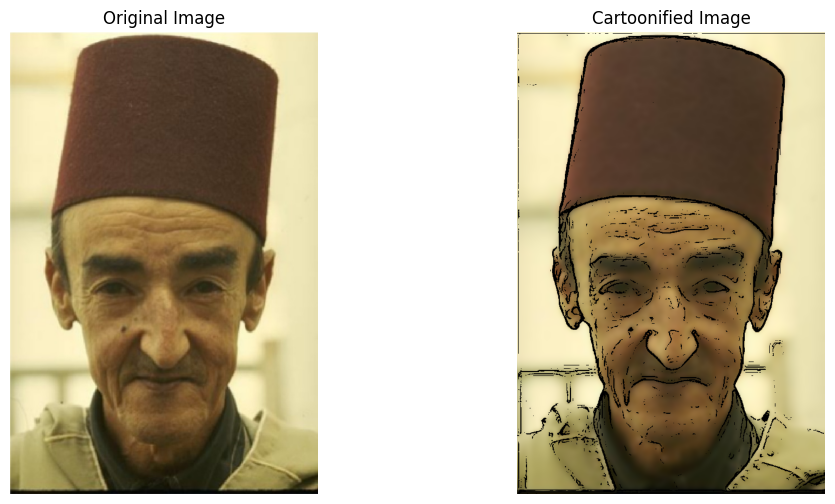

In [40]:
# overlap the edge mask with the bilateral filtered image
cartoon_img = cv2.bitwise_and(bilateral_filtered_img, bilateral_filtered_img, mask=edge_mask)
# plot the orignal image and the cartoonified image
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img_rgb)
axes[1].imshow(cv2.cvtColor(cartoon_img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Image')
axes[1].set_title('Cartoonified Image')
for ax in axes:
    ax.axis('off')
plt.show()